In [1]:
# ✅ STEP 1 — Import all libraries
import pandas as pd
import numpy as np
from yahooquery import Ticker
import matplotlib.pyplot as plt
import streamlit as st
from datetime import datetime

# Optional: suppress warnings for clean output
import warnings
warnings.filterwarnings("ignore")


In [3]:
# ✅ STEP 2 — Clean YahooQuery Data (TZ-SAFE VERSION)

import pandas as pd
from yahooquery import Ticker

# Fetch data
ticker = Ticker("MSFT")
data = ticker.history(period="1y")

# Reset multi-index
data = data.reset_index()

# Keep only date & close
data = data[['date', 'close']]
data.columns = ['date', 'Close']

# ✅ FORCE timezone removal (THIS FIXES YOUR ERROR)
data['date'] = pd.to_datetime(data['date'], utc=True).dt.tz_convert(None)

# Set index
data.set_index('date', inplace=True)

# ✅ Calculate SMAs
data['SMA_20'] = data['Close'].rolling(20).mean()
data['SMA_50'] = data['Close'].rolling(50).mean()

# ✅ Verify output
data.tail()


,Close,SMA_20,SMA_50
date,,,
2025-11-28 00:00:00,492.010010,497.849503,510.592999
2025-12-01 00:00:00,486.739990,496.296002,509.969199
2025-12-02 00:00:00,490.000000,494.944501,509.480198
2025-12-03 00:00:00,477.730011,493.114500,508.850198
2025-12-04 21:00:02,480.839996,491.798500,508.263998


In [4]:
# ✅ STEP 3 — Define the autonomous agent
class AdvancedTradingAgent:
    def __init__(self, name, initial_cash):
        self.name = name
        self.cash = initial_cash
        self.position = 0
        self.portfolio_history = []
        self.action_history = []

    def observe(self, row):
        self.current_price = row['Close']
        self.current_row = row

    def reason(self):
        row = self.current_row
        if not np.isnan(row['SMA_20']) and not np.isnan(row['SMA_50']):
            if row['SMA_20'] > row['SMA_50']:
                self.next_action = 'BUY'
            else:
                self.next_action = 'SELL'
        else:
            self.next_action = 'HOLD'

    def act(self):
        if self.next_action == 'BUY' and self.cash >= self.current_price:
            shares_to_buy = self.cash // self.current_price
            self.position += shares_to_buy
            self.cash -= shares_to_buy * self.current_price
        elif self.next_action == 'SELL' and self.position > 0:
            self.cash += self.position * self.current_price
            self.position = 0
        
        portfolio_value = self.cash + self.position * self.current_price
        self.portfolio_history.append(portfolio_value)
        self.action_history.append(self.next_action)


In [5]:
# ✅ STEP 4 — Initialize and run agent
initial_cash = 100000
agent = AdvancedTradingAgent("OmegaAgent", initial_cash)

for idx, row in data.iterrows():
    agent.observe(row)
    agent.reason()
    agent.act()

# Create portfolio DataFrame
adv_portfolio = pd.DataFrame({
    'Date': data.index,
    'Portfolio': agent.portfolio_history,
    'Action': agent.action_history,
    'Stock Price': data['Close']
}).set_index('Date')

adv_portfolio.tail(10)


,Portfolio,Action,Stock Price
Date,,,
2025-11-20 00:00:00,106710.135681,SELL,478.429993
2025-11-21 00:00:00,106710.135681,SELL,472.119995
2025-11-24 00:00:00,106710.135681,SELL,474.000000
2025-11-25 00:00:00,106710.135681,SELL,476.989990
2025-11-26 00:00:00,106710.135681,SELL,485.500000
2025-11-28 00:00:00,106710.135681,SELL,492.010010
2025-12-01 00:00:00,106710.135681,SELL,486.739990
2025-12-02 00:00:00,106710.135681,SELL,490.000000
2025-12-03 00:00:00,106710.135681,SELL,477.730011


In [6]:
# ✅ STEP 5 — Compute metrics
adv_portfolio['Returns'] = adv_portfolio['Portfolio'].pct_change().fillna(0)
total_return = (adv_portfolio['Portfolio'].iloc[-1] / adv_portfolio['Portfolio'].iloc[0] - 1) * 100
max_drawdown = ((adv_portfolio['Portfolio'].cummax() - adv_portfolio['Portfolio']).max() / adv_portfolio['Portfolio'].cummax().max()) * 100

print(f"Total Return: {total_return:.2f}%")
print(f"Max Drawdown: {max_drawdown:.2f}%")


Total Return: 6.71%
Max Drawdown: 13.62%


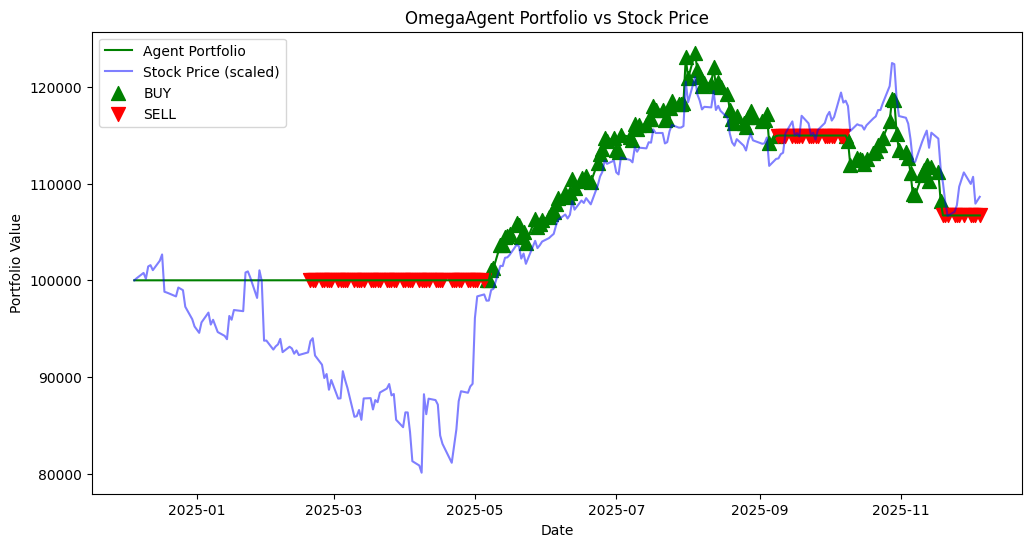

In [7]:
# ✅ STEP 6 — Portfolio vs Stock Price
plt.figure(figsize=(12,6))
plt.plot(adv_portfolio['Portfolio'], label='Agent Portfolio', color='green')
plt.plot(adv_portfolio['Stock Price'] * (initial_cash / adv_portfolio['Stock Price'].iloc[0]), 
         label='Stock Price (scaled)', color='blue', alpha=0.5)

# Mark buy/sell actions
buys = adv_portfolio[adv_portfolio['Action'] == 'BUY']
sells = adv_portfolio[adv_portfolio['Action'] == 'SELL']
plt.scatter(buys.index, buys['Portfolio'], marker='^', color='green', s=100, label='BUY')
plt.scatter(sells.index, sells['Portfolio'], marker='v', color='red', s=100, label='SELL')

plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.title(f"{agent.name} Portfolio vs Stock Price")
plt.legend()
plt.show()


In [8]:
# ✅ STEP 7 — Streamlit App
st.title("Autonomous Trading Agent Dashboard")

# Show portfolio plot
st.subheader("Portfolio vs Stock Price")
st.line_chart(adv_portfolio[['Portfolio', 'Stock Price']])

# Show last 10 actions
st.subheader("Last 10 Agent Actions")
st.dataframe(adv_portfolio.tail(10))

# Show metrics
st.subheader("Performance Metrics")
st.write(f"Total Return: {total_return:.2f}%")
st.write(f"Max Drawdown: {max_drawdown:.2f}%")


2025-12-05 01:21:49.709 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:21:49.799 
  command:

    streamlit run /home/amenibelhaj/autonomous-fin-agent/venv/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-12-05 01:21:49.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:21:49.804 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:21:49.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:21:49.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:21:49.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:21:

In [9]:
# ✅ STEP 8 — Risk Management Tool
def simple_risk_assessment(cash, position, price, max_exposure=0.5):
    """
    Ensures the agent never invests more than max_exposure of total portfolio.
    """
    portfolio_value = cash + position * price
    max_invest = portfolio_value * max_exposure
    return max_invest


In [10]:
# ✅ STEP 9 — Multi-Agent AdvancedTradingAgent
class MultiStrategyAgent(AdvancedTradingAgent):
    def __init__(self, name, initial_cash, strategy="SMA"):
        super().__init__(name, initial_cash)
        self.strategy = strategy

    def reason(self):
        row = self.current_row
        if self.strategy == "SMA":
            if not np.isnan(row['SMA_20']) and not np.isnan(row['SMA_50']):
                self.next_action = 'BUY' if row['SMA_20'] > row['SMA_50'] else 'SELL'
            else:
                self.next_action = 'HOLD'
        elif self.strategy == "Conservative":
            # Only buy if SMA_20 > SMA_50 and price < previous price
            if not np.isnan(row['SMA_20']) and not np.isnan(row['SMA_50']):
                if row['SMA_20'] > row['SMA_50'] and row['Close'] < self.current_price:
                    self.next_action = 'BUY'
                else:
                    self.next_action = 'SELL'
            else:
                self.next_action = 'HOLD'


In [11]:
# ✅ STEP 10 — Initialize two agents
agent_sma = MultiStrategyAgent("SMAAgent", initial_cash, strategy="SMA")
agent_cons = MultiStrategyAgent("ConservativeAgent", initial_cash, strategy="Conservative")

# Create empty DataFrames to store results
portfolio_sma = []
portfolio_cons = []

for idx, row in data.iterrows():
    # SMA Agent
    agent_sma.observe(row)
    agent_sma.reason()
    # Apply risk management
    max_invest = simple_risk_assessment(agent_sma.cash, agent_sma.position, agent_sma.current_price)
    if agent_sma.next_action == 'BUY' and agent_sma.cash > max_invest:
        agent_sma.next_action = 'HOLD'
    agent_sma.act()
    portfolio_sma.append(agent_sma.portfolio_history[-1])
    
    # Conservative Agent
    agent_cons.observe(row)
    agent_cons.reason()
    max_invest = simple_risk_assessment(agent_cons.cash, agent_cons.position, agent_cons.current_price)
    if agent_cons.next_action == 'BUY' and agent_cons.cash > max_invest:
        agent_cons.next_action = 'HOLD'
    agent_cons.act()
    portfolio_cons.append(agent_cons.portfolio_history[-1])

# Combine results into DataFrame
multi_portfolio = pd.DataFrame({
    'Date': data.index,
    'SMAAgent': portfolio_sma,
    'ConservativeAgent': portfolio_cons,
    'Stock Price': data['Close']
}).set_index('Date')

multi_portfolio.tail(10)


,SMAAgent,ConservativeAgent,Stock Price
Date,,,
2025-11-20 00:00:00,100000.0,100000.0,478.429993
2025-11-21 00:00:00,100000.0,100000.0,472.119995
2025-11-24 00:00:00,100000.0,100000.0,474.000000
2025-11-25 00:00:00,100000.0,100000.0,476.989990
2025-11-26 00:00:00,100000.0,100000.0,485.500000
2025-11-28 00:00:00,100000.0,100000.0,492.010010
2025-12-01 00:00:00,100000.0,100000.0,486.739990
2025-12-02 00:00:00,100000.0,100000.0,490.000000
2025-12-03 00:00:00,100000.0,100000.0,477.730011


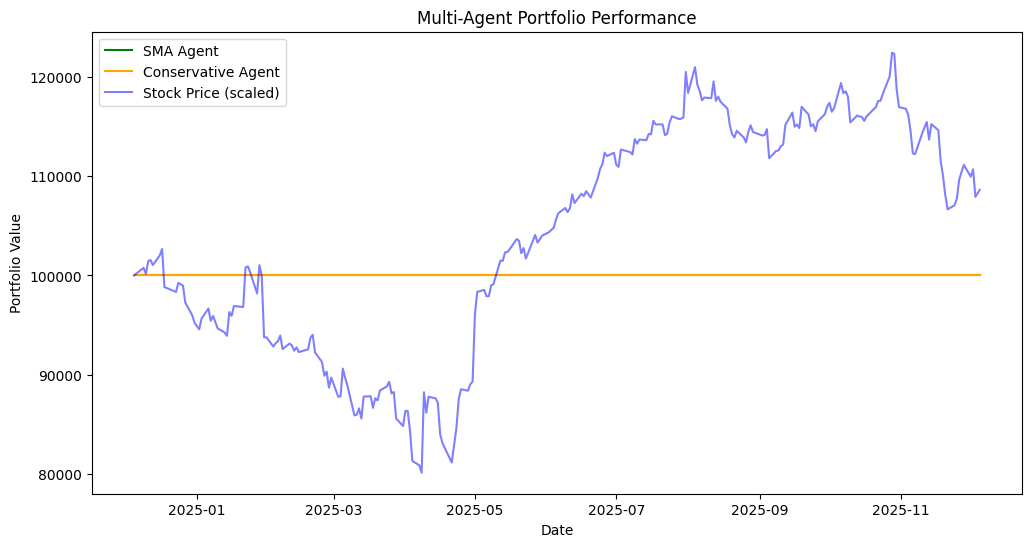

In [12]:
# ✅ STEP 11 — Multi-Agent Portfolio Visualization
plt.figure(figsize=(12,6))
plt.plot(multi_portfolio['SMAAgent'], label='SMA Agent', color='green')
plt.plot(multi_portfolio['ConservativeAgent'], label='Conservative Agent', color='orange')
plt.plot(multi_portfolio['Stock Price'] * (initial_cash / multi_portfolio['Stock Price'].iloc[0]), 
         label='Stock Price (scaled)', color='blue', alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.title("Multi-Agent Portfolio Performance")
plt.legend()
plt.show()


In [13]:
# ✅ STEP 12 — Streamlit Multi-Agent Dashboard
st.title("Multi-Agent Autonomous Trading Dashboard")

st.subheader("Multi-Agent Portfolio vs Stock Price")
st.line_chart(multi_portfolio)

st.subheader("Last 10 SMA Agent Actions")
st.dataframe(pd.DataFrame({
    'Portfolio': agent_sma.portfolio_history[-10:],
    'Action': agent_sma.action_history[-10:]
}, index=multi_portfolio.index[-10:]))

st.subheader("Last 10 Conservative Agent Actions")
st.dataframe(pd.DataFrame({
    'Portfolio': agent_cons.portfolio_history[-10:],
    'Action': agent_cons.action_history[-10:]
}, index=multi_portfolio.index[-10:]))


2025-12-05 01:24:29.805 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:24:29.807 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:24:29.808 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:24:29.811 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:24:29.812 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:24:29.814 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:24:29.953 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-05 01:24:29.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()